# Linear Discriminant Analysis

Let $Y$ denote the outcome of a $K$ class classifier. Looking to estimate:
$$
P(Y = k | X = x)
$$

or $P(Y|X)$ for short. Let $f_k(x)$ denote the class-conditional density function of $X$.
$$
f_k(x) = P(X = x | Y = k)
$$

From Bayes' Rule, we get
$$
P(Y=k|X=x) = \frac{f_k(x) \pi_k}{\sum_{j=1}^K f_j(x) \pi_j}
$$

where $\pi_k = P(Y = k)$.

So we can decide classes if we can compute the $f_k(x)$. Assume the $f_k(x)$ are (multivariate) normal variables.

If we compare two classes $k$ and $j$, we can look at the log-probability ratio

\begin{align*}
\log \frac{P(Y = k | X= x)}{P(Y=j | X = x)} &= \log \frac{f_k(x)}{f_j(x)} + \log \frac{\pi_k}{\pi_j} \\
&= -\frac{1}{2} \langle(\mu_k + \mu_j), \Sigma^{-1} (\mu_k - \mu_j) \rangle + \langle x, \Sigma^{-1} (\mu_k - \mu_j)\rangle + \log \frac{\pi_k}{\pi_j}
\end{align*}

For LDA, we assume that the covariance is common to all classes.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import statsmodels.api as sm

matplotlib.rcParams['figure.figsize'] = (20, 10)

In [ ]:
def generate_classifier_data(c_1, c_2, c_3, sigma, size_1, size_2, size_3, seed):
  rng = numpy.random.default_rng(seed=seed)
  class1 = rng.multivariate_normal(c_1, sigma, size=size_1)
  class2 = rng.multivariate_normal(c_2, sigma, size=size_2)
  class3 = rng.multivariate_normal(c_3, sigma, size=size_3)
  ys1 = numpy.zeros(shape=(class1.shape[0],1))
  ys2 = numpy.ones(shape=(class2.shape[0], 1))
  ys3 = 2*numpy.ones(shape=(class3.shape[0],1))
  xs = numpy.vstack((class1, class2, class3))
  ys = numpy.vstack((ys1, ys2, ys3))
  return (xs, ys)


In [ ]:
c_1 = numpy.array([1, -1, 1])
c_2 = numpy.array([-1, 1, 2])
c_3 = numpy.array([-1, -1, -1])
sigma_12 = numpy.array([[0.5, 0.3, 0.1], [-0.2, 0.7, 0.2], [-0.4, 0.5, -0.6]])
sigma = numpy.matmul(sigma_12.T, sigma_12)#numpy.array([[1, 0], [0, 1]])
xs, ys = generate_classifier_data(c_1, c_2,c_3, sigma, 5000, 500, 1500, 8675309)

In [ ]:
xs.shape

(7000, 3)

In [ ]:
ys.shape

(7000, 1)

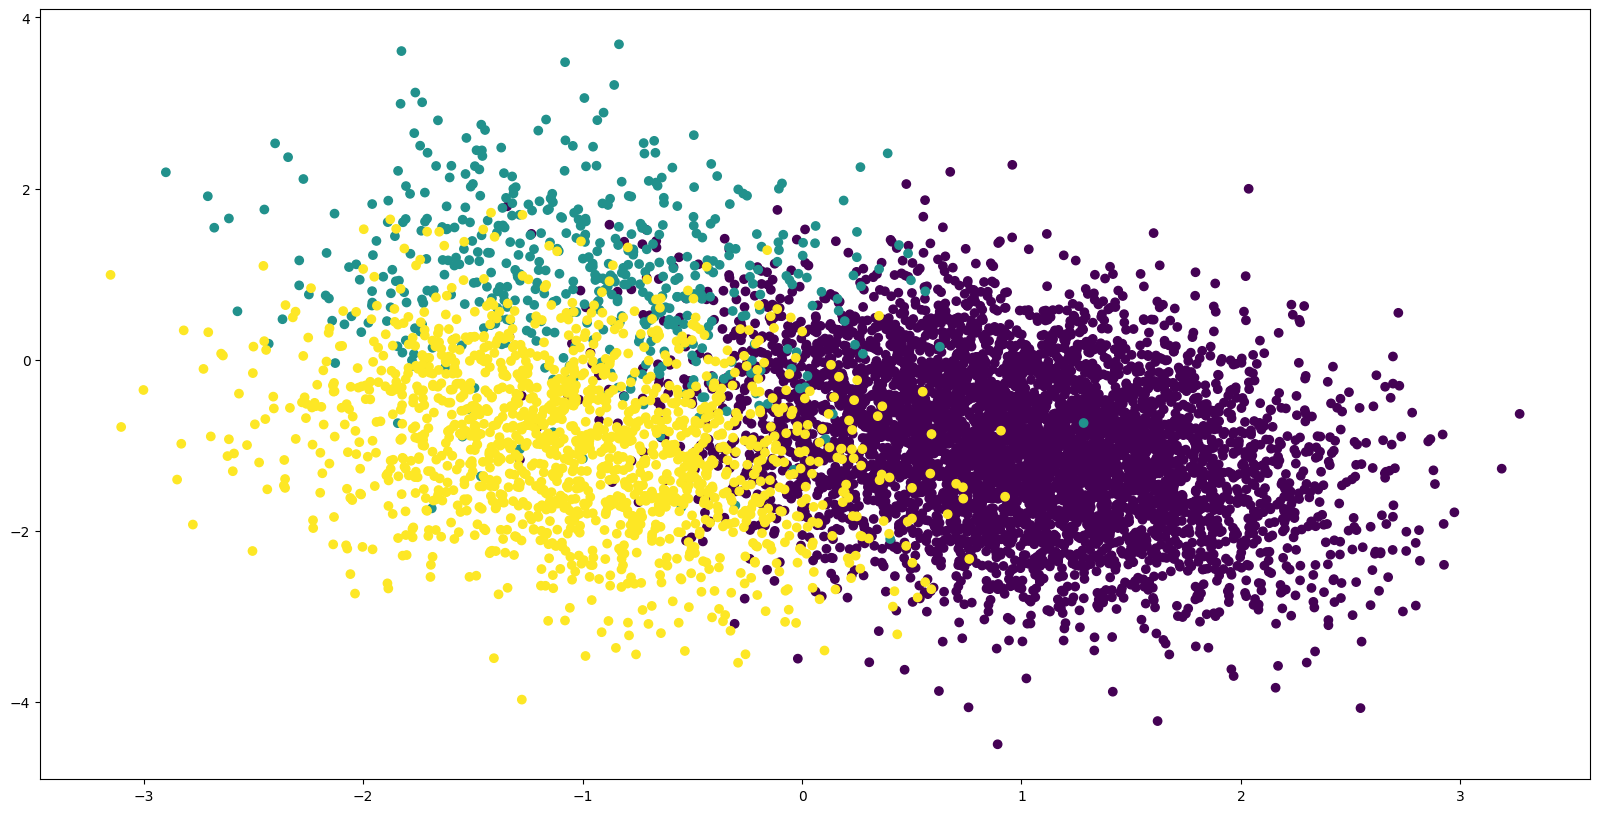

In [ ]:
ax1 = plt.scatter(xs[:,0], xs[:,1], c=ys)

In [ ]:
class LDAClassifier():
  def __init__(self):
    pass

  def fit(self, xs, ys):
    n_0 = numpy.where(ys==0.0)[0].shape[0]
    n_1 = numpy.where(ys==1.0)[0].shape[0]
    n_2 = numpy.where(ys==2.0)[0].shape[0]
    x_0 = xs[numpy.where(ys == 0.0)[0],:]
    x_1 = xs[numpy.where(ys == 1.0)[0], :]
    x_2 = xs[numpy.where(ys == 2.0)[0], :]
    self.mu_0 = numpy.mean(x_0, axis=0)
    self.mu_1 = numpy.mean(x_1, axis=0)
    self.mu_2 = numpy.mean(x_2, axis=0)
    N = n_0 + n_1 + n_2
    sigma_0 = 1/(N - 3)*numpy.matmul((x_0 - self.mu_0).T, x_0 - self.mu_0)
    sigma_1 = 1/(N - 3)*numpy.matmul((x_1 - self.mu_1).T, x_1 - self.mu_1)
    sigma_2 = 1/(N - 3)*numpy.matmul((x_2 - self.mu_1).T, x_2 - self.mu_2)

    self.pi_0 = n_0/N
    self.pi_1 = n_1/N
    self.pi_2 = n_2/N
    self.sigma = sigma_0 + sigma_1 + sigma_2
    return LDAClassifierResult(self.pi_0,
                               self.pi_1,
                               self.pi_2,
                               self.mu_0,
                               self.mu_1,
                               self.mu_2,
                               self.sigma)

class LDAClassifierResult():
  def __init__(self, pi_0, pi_1, pi_2, mu_0, mu_1, mu_2, sigma):
    self.pi_0 = pi_0
    self.pi_1 = pi_1
    self.pi_2 = pi_2
    self.mu_0 = mu_0
    self.mu_1 = mu_1
    self.mu_2 = mu_2
    self.sigma = sigma

  def predict(self, x):
    LL = self._log_loss(x)
    return self._softmax(LL)

  def _softmax(self, vec):
    new_vec = numpy.append([0], vec)
    return numpy.exp(new_vec)/(numpy.sum(numpy.exp(new_vec)))


  def viz_everything(self):
    sigma_inv = numpy.linalg.inv(self.sigma)
    x_hat = numpy.matmul(sigma_inv, self.mu_0 - self.mu_1)
    offset = numpy.log(self.pi_1/self.pi_0) + 1/2*numpy.log(numpy.linalg.det(self.sigma)*2*numpy.pi)
    slope = -1*x_hat[0]/x_hat[1]
    intercept = offset/x_hat[1]
    t = numpy.arange(-2, 2, 0.1)
    return (t, slope*t + intercept)

  def _log_loss(self, x):
    sigma_inv = numpy.linalg.inv(self.sigma)
    sigma_inv_dist_01 = numpy.matmul(sigma_inv, self.mu_1 - self.mu_0)
    first_term_01 = -1/2*numpy.matmul(self.mu_1 + self.mu_0, sigma_inv_dist_01)
    second_term_01 = numpy.matmul(x, sigma_inv_dist_01)
    third_term_01 = numpy.log(self.pi_1/self.pi_0)
    sigma_inv_dist_02 = numpy.matmul(sigma_inv, self.mu_2 - self.mu_0)
    first_term_02 = -1/2*numpy.matmul(self.mu_2 + self.mu_0, sigma_inv_dist_02)
    second_term_02 = numpy.matmul(x, sigma_inv_dist_02)
    third_term_02 = numpy.log(self.pi_2/self.pi_0)
    return (first_term_01 + second_term_01 + third_term_01,
            first_term_02 + second_term_02 + third_term_02 )

In [ ]:
model = LDAClassifier()

In [ ]:
result = model.fit(xs, ys)

In [ ]:
result.sigma

array([[ 0.45025365, -0.17803749,  0.25311955],
       [-0.17803749,  0.81829993, -0.12215076],
       [ 0.25311955, -0.12215076,  0.42925711]])

In [ ]:
result.predict(numpy.array([1, -1, 1]))

array([9.99478467e-01, 1.66209905e-07, 5.21366816e-04])

In [ ]:
t, line = result.viz_everything()

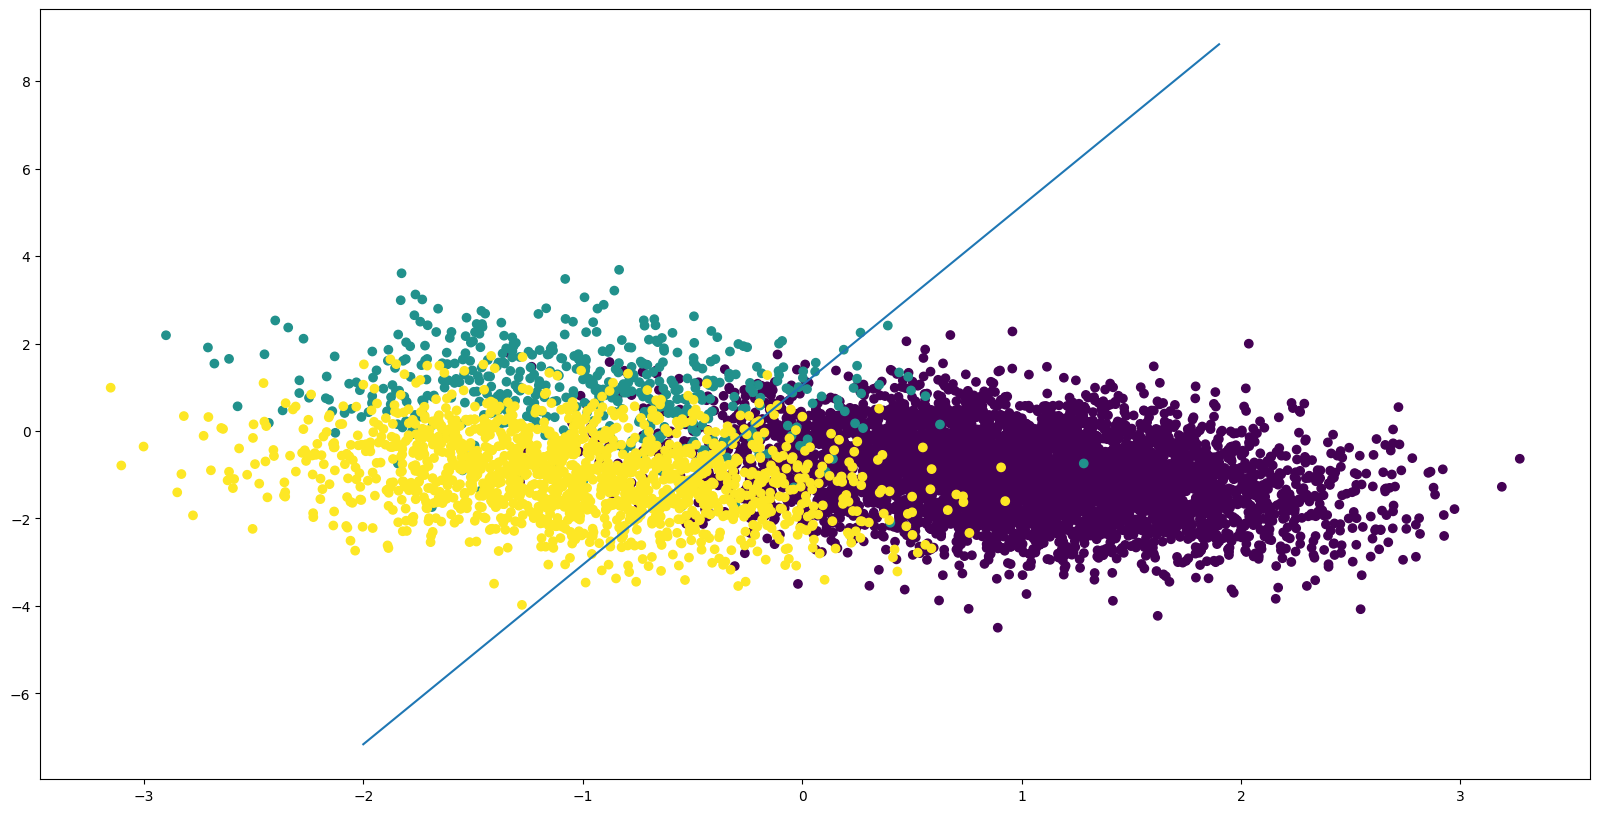

In [ ]:
plt.plot(t, line)
plt.scatter(xs[:,0], xs[:,1], c=ys)

In [ ]:
numpy.linalg.inv(sigma)

array([[ 3.54589711,  0.49778518, -2.00429806],
       [ 0.49778518,  1.33766063,  0.12060875],
       [-2.00429806,  0.12060875,  3.69939915]])

# Supervised Dimensionality Reduction

In [ ]:
def generate_classifier_data(rnge, k, d, sizes, seed):


    rng = numpy.random.default_rng(seed=seed)
    cs = rng.uniform(rnge[0], rnge[1], size=(k, d))
    mb = rng.normal(loc=0, scale=.3, size=(k,d))
    noise = rng.normal(loc=0, scale=0.01, size=(d,d))
    sigma_signal = numpy.matmul(mb.T, mb)
    noisy_sigma = sigma_signal + noise
    sigma = numpy.matmul(noisy_sigma.T, noisy_sigma)
    classes = [rng.multivariate_normal(c, sigma, size=size) for c, size in zip(cs,sizes)]
    ys = [j*numpy.ones(shape=(size, 1)) for j, size in enumerate(sizes)]
    xs = numpy.vstack(classes)
    ys = numpy.vstack(ys)
    return (xs, ys)


In [ ]:
rnge = [-10,10]
k = 3
d = 300
sizes = [5000, 1000, 2000]
X, y = generate_classifier_data(rnge, k, d, sizes, 8675309)
X.shape

(8000, 300)

In [ ]:
model = LDAClassifier()
result = model.fit(X,y)

In [ ]:
numpy.linalg.eig(numpy.array([[1, 0.1], [0.1, 1]]))

EigResult(eigenvalues=array([1.1, 0.9]), eigenvectors=array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]]))

In [ ]:
inv_sigma = numpy.linalg.inv(result.sigma)
p = numpy.linalg.eig(inv_sigma)[1][:,-2:]

In [ ]:
numpy.matmul(p.T, p)

array([[ 1.00000000e+00, -1.57730781e-09],
       [-1.57730781e-09,  1.00000000e+00]])

In [ ]:
numpy.linalg.eigvals(result.sigma)

array([9.15160811e+02, 7.03881725e+02, 5.05724071e+02, 1.18731783e-01,
       1.15508915e-01, 1.12356118e-01, 1.11279838e-01, 1.08887217e-01,
       1.08725840e-01, 1.06636537e-01, 1.04403102e-01, 1.03190044e-01,
       1.01565132e-01, 9.90395376e-02, 9.86812262e-02, 9.67978645e-02,
       9.61230076e-02, 9.49177096e-02, 9.31887971e-02, 9.22454352e-02,
       9.08785779e-02, 8.99980883e-02, 8.95821560e-02, 8.73774879e-02,
       8.66069465e-02, 8.63826642e-02, 8.51446059e-02, 8.39977875e-02,
       8.31914618e-02, 8.00820894e-02, 8.19235133e-02, 8.14345931e-02,
       7.90606918e-02, 7.77226604e-02, 7.71547496e-02, 7.62277048e-02,
       7.60898096e-02, 7.52768513e-02, 7.43011427e-02, 7.30273349e-02,
       7.27805918e-02, 7.16902076e-02, 7.09275665e-02, 6.96918216e-02,
       6.82302175e-02, 6.48526541e-02, 6.71321755e-02, 6.66597516e-02,
       6.54728738e-02, 6.60060726e-02, 6.37195568e-02, 6.26922775e-02,
       6.20023666e-02, 6.17203208e-02, 5.63295199e-02, 6.05159177e-02,
      

In [ ]:
X_p = numpy.matmul(X, p)

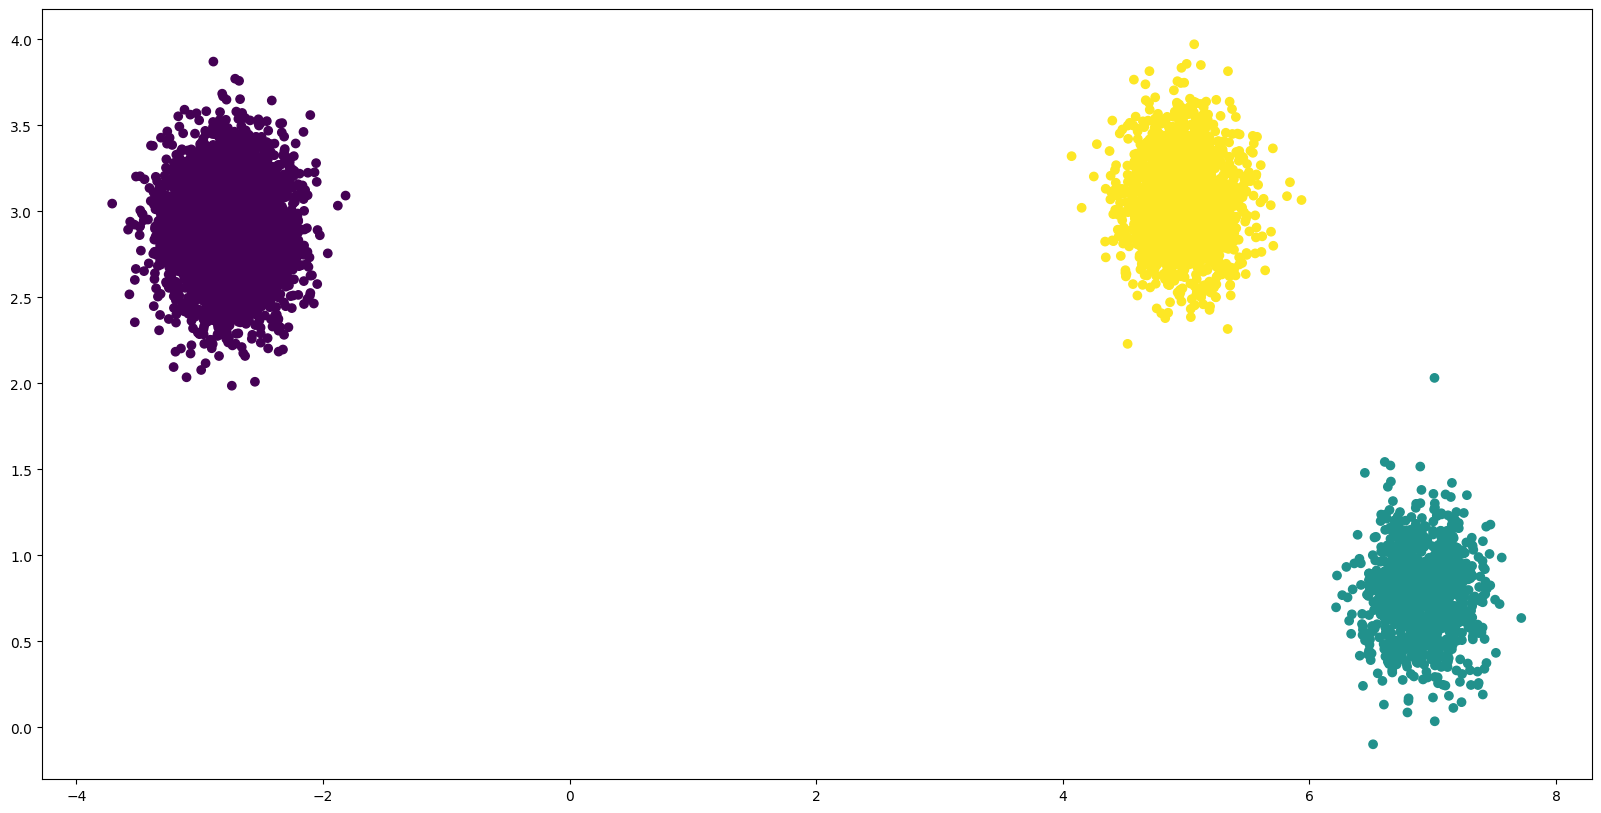

In [ ]:
plt.scatter(X_p[:,0], X_p[:,1], c=y)
plt.show()